gprlim path:
/Users/alliswell48/gprlim/gprlim/__init__.py

utils_inpaint module path:
/Users/alliswell48/radio_gpr_work/shao1/2.corrupt_data/utils_load.py

gp_utils path:
/Users/alliswell48/radio_gpr_work/shao1/2.corrupt_data/../../gp_utils.py


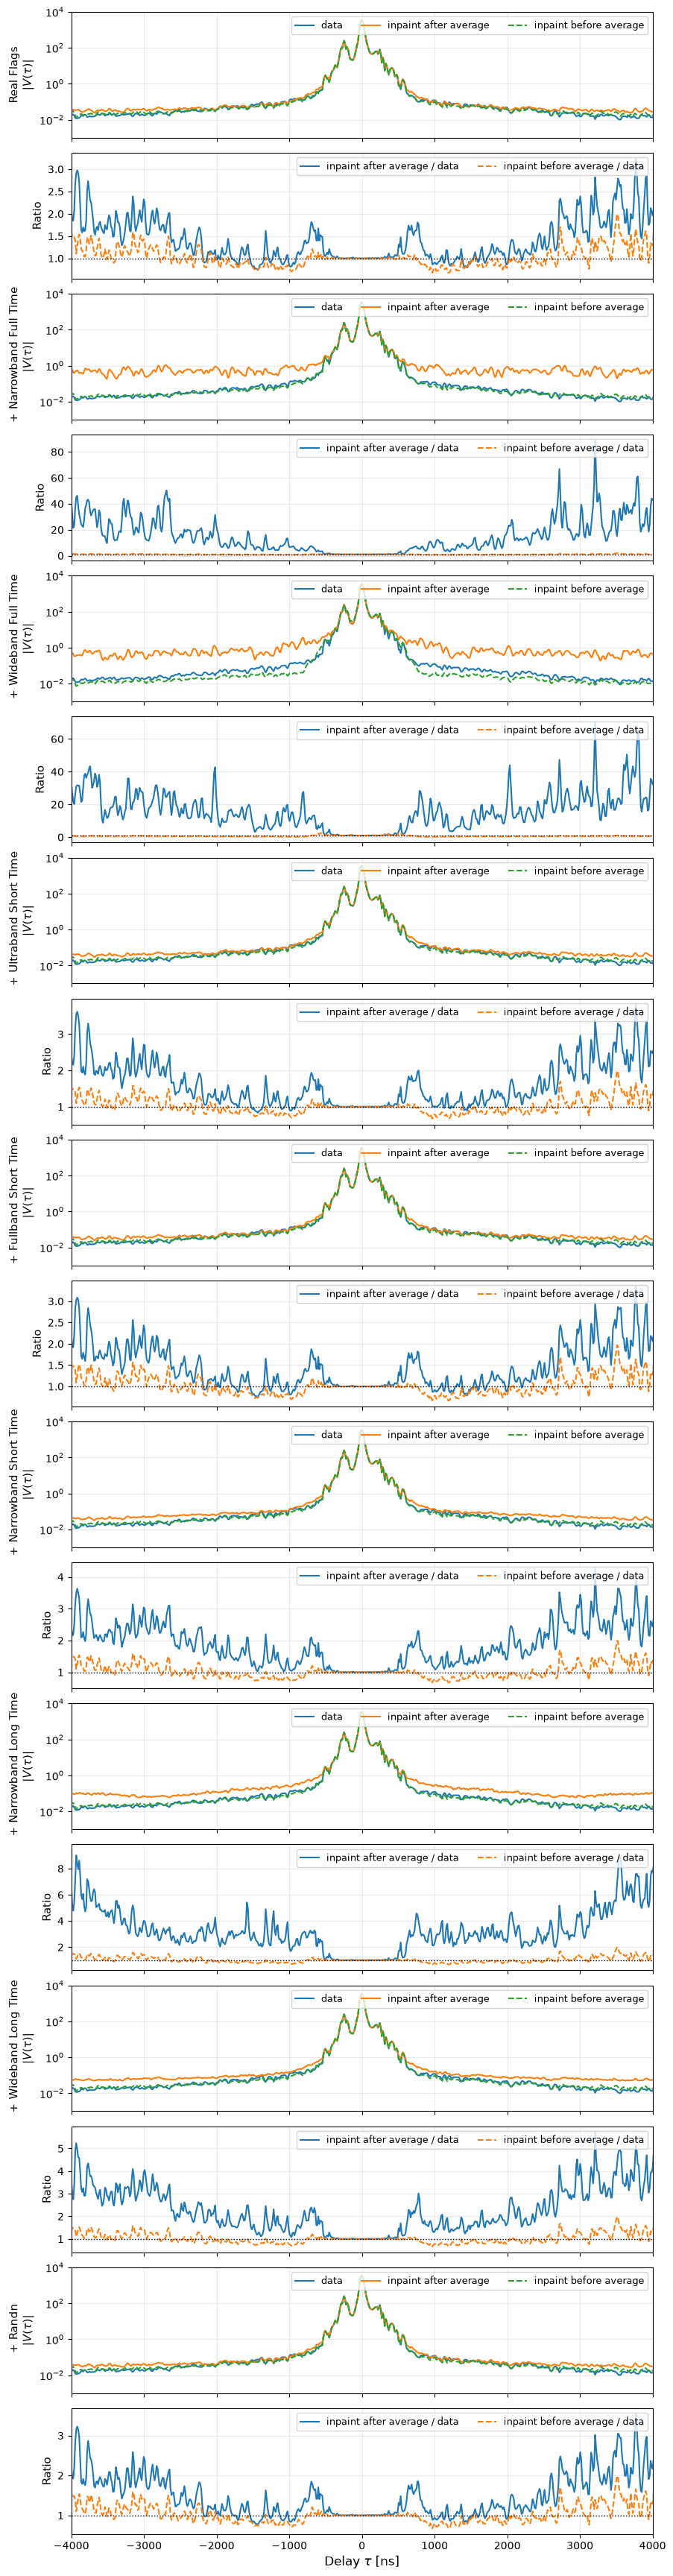

In [10]:
import gc
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch
import glob

import sys
sys.path.append('./')
import utils_load
from utils_load import save_vd_inp,load_vd_inp



from pyuvdata import UVData
import bayeslim as ba

import gpytorch

import gprlim
from gprlim import kernels
from bayeslim.fft import FFT


torch.set_default_dtype(torch.float64)

sys.path.append('../../')
import gp_utils
import importlib
importlib.reload(gp_utils)

import inspect
print("gprlim path:")
print(gprlim.__file__)

print("\nutils_inpaint module path:")
print(inspect.getmodule(save_vd_inp).__file__)

print("\ngp_utils path:")
print(gp_utils.__file__)

import importlib
import utils_Vtau

importlib.reload(utils_Vtau)

from utils_Vtau import (
    coherent_reference_average,
    coherent_inpaint_average,
    create_delay_figure,
    get_delay_quantities,
    plot_delay_histograms,
    get_ratio_hist_values,
    plot_reference_delay_curves,
    plot_method_curves,
    plot_ratio_histogram,
    format_delay_axis,
    format_delay_hist_axis,
    format_ratio_axis,
    format_ratio_hist_axis,
    finalize_delay_figure,
    load_gain_results
)









gpytorch.settings.max_cholesky_size._set_value(1_000)

torch.set_default_dtype(torch.float64)
device = 'cpu'



# 1. load all the data (except for the first 50 integrations which are wrong)
flag_file='/Users/alliswell48/radio_gpr_work/shao1/1.ideal_mock/gpr_data/version2/zen.h6c_idr3.2459951.flag_waterfall_round2.npz'
freq_chans = range(0, 600)
time_ints = range(80, 1680)

#2.
inflate_data = False
add_gains = True
add_noise = False
add_reflection = False



# 3.specify the inpaint method [ '2d','2d_1d', '1d_1d', 'freq', 'time']
#inpaint_method_all = ['1d_1d','2d_1d']
inpaint_method_all = [ '2d_1d']  #136

# 4. specify the number of time chunks to operate over
Ntime_chunks = 200


#5.real falg
add_real_flags = True #

# 6.simulate flags, can add None+real
flag_types_all = [
    None,
    'narrowband_full_time',
    'wideband_full_time',  #136
    'ultraband_short_time',
    'fullband_short_time',
    'narrowband_short_time',
    'narrowband_long_time',
    'wideband_long_time',
    'randn',
]



#7. polo
polsi='ee'#,'nn'

# 8. baseline
blall=[(0, 5)]  #136

# 9.specify data
#dfile = 'gpr_data/version2/zen.h6c_idr2_validation.sum.uvh5'
dfile = sorted(glob.glob('/Volumes/YUNYUNShao/gpr_data/corrupted data/zen.h6c_idr2_validation.24582*.sum.coupled.h5'))



# load autocorrelation and metadata
vd, meta = gp_utils.load_uvdata(
    dfile, bls=[(0, 0)], pols=[polsi], time_ints=time_ints, freq_chans=freq_chans,
)
autocorr = vd.data[0,0]

freqs = meta['freqs'] / 1e6
lsts = meta['lsts']
times = (meta['times'] - meta['times'][0]) * 24 * 3600
Ntimes = len(times)
Nfreqs = len(freqs)
reds = meta['reds']

# get antenna information
antp = meta['antp']
ants = list(antp.keys())
antpos = torch.stack(list(antp.values()))

# get baseline information
red_bls = meta['bls']
all_pols = meta['pols']
reds = meta['reds']

# get noise standard deviation
noise_amp = autocorr.real / np.sqrt(np.diff(meta['times'])[0]*24*3600 * np.diff(meta['freqs'])[0])

# pick a representative baseline to load and model (start with 0)



for bl in blall:
    #bl = (0, 5)

    # this gets the index in the redundant set that this baseline falls in
    red_ind = np.where([bl in red for red in reds])[0][0]
    bls = reds[red_ind][:]
    bl_vec = antp[bls[0][1]] - antp[bls[0][0]]
    bl_len = bl_vec.norm()


    # load single baseline data
    vd, meta = gp_utils.load_uvdata(
        dfile,
        bls=bls,
        time_ints=time_ints,
        freq_chans=freq_chans,
        pols=[polsi], #['nn']
        device=device,
    )

    #inflate_data = True

    #False
    if inflate_data and vd.Nbls == 1:
        vd = vd.inflate_by_redundancy(bls=reds[red_ind])

    #add_reflection = False

    if add_reflection:
        vd.data *= (1 + 1e-2 * (torch.exp(2j*np.pi*2000e-9*freqs*1e6) + torch.exp(-2j*np.pi*2000e-9*freqs*1e6)))

    #add_gains = False
    #True
    if add_gains:
        G = torch.randn(vd.Nbls) / 10 + 1
        vd.data *= G[:, None, None]


    # fg 1e0
    #add_noise = False

    ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-10  



    if add_noise:
        ns_draw = torch.randn_like(vd.data) * noise_amp * 1e-6
        vd.data += ns_draw




    # 1D FT across frequency
    FT1 = FFT(dim=-1, N=vd.data.shape[-1], ndim=2, window='bh', dx=(freqs[1]-freqs[0])/1e3)

   




    # ============================================================
    # Simulate flags
    # ============================================================


    # ============================================================
    # Create figure
    # ============================================================
    fig, axes = plt.subplots(2 * len(flag_types_all), 1, figsize=(10, 4 * len(flag_types_all)), sharex=True)
    axes = np.atleast_1d(axes)

    for flag_idx, flag_typesi in enumerate(flag_types_all):

        ax_delay = axes[2 * flag_idx]
        ax_ratio = axes[2 * flag_idx + 1]

        # Figure title
        if flag_typesi is None:
            flag_title = "Real Flags" if add_real_flags else "No Flags"
        else:
            simulated_flag_title = flag_typesi.replace("_", " ").title()
            flag_title = f" + {simulated_flag_title}" if add_real_flags else simulated_flag_title

        # Simulated flags
        if flag_typesi is None:
            flags = torch.zeros((Ntimes, Nfreqs), dtype=torch.bool, device=device)
        else:
            flags = gp_utils.simulate_flags([flag_typesi], [20], Ntimes, Nfreqs, seed=0).to(device=device, dtype=torch.bool)

        flags = flags.expand(vd.data.shape[-3:]).clone()

        if add_gains and flag_typesi is not None:
            for i in range(1, vd.Nbls):
                flags[i] = gp_utils.simulate_flags([flag_typesi], [20], Ntimes, Nfreqs, seed=i).to(device=device, dtype=torch.bool)

        # Real flags
        if add_real_flags:
            flg = np.load(flag_file)["flags"][time_ints][:, freq_chans, 0]
            real_flags = torch.as_tensor(flg, dtype=torch.bool, device=device)
            flags |= real_flags.unsqueeze(0)

        flagged_times = flags.all(dim=-1, keepdim=True).expand_as(flags)

        noise_var = noise_amp.pow(2).expand(flags.shape).clone() * 1e-5
        noise_var[flags] = noise_var.mean() * 1e6

        for inpaint_method in inpaint_method_all:

            gain_vd_inp, gain_vd_true, gain_vd_inp_then_avg = load_gain_results(
                root_dir="/Volumes/YUNYUNShao/radio_gpr_work_great_lake/4.shao_instru_gain_less/inpaint_results",
                bl=bl, flag_typesi=flag_typesi, add_real_flags=add_real_flags,
                inpaint_method=inpaint_method, freq_chans=freq_chans,
                time_ints=time_ints, polsi=polsi, Ntime_chunks=Ntime_chunks, device=device,
            )

            vd_avg = gain_vd_true
            vd_flg_avg = gain_vd_inp
            vd_inp_avg = gain_vd_inp_then_avg

            V_true_tau = FT1(vd_avg[0, 0, 0]).abs().mean(0)
            V_avg_then_inp_tau = FT1(vd_flg_avg[0, 0, 0]).abs().mean(0)
            V_inp_then_avg_tau = FT1(vd_inp_avg[0, 0, 0]).abs().mean(0)

            ax_delay.plot(FT1.freqs, V_true_tau, label="data")
            ax_delay.plot(FT1.freqs, V_avg_then_inp_tau, label="inpaint after average")
            ax_delay.plot(FT1.freqs, V_inp_then_avg_tau, linestyle="--", label="inpaint before average")

            denominator = V_true_tau.clamp_min(torch.finfo(V_true_tau.dtype).eps)

            ax_ratio.plot(FT1.freqs, V_avg_then_inp_tau / denominator, label="inpaint after average / data")
            ax_ratio.plot(FT1.freqs, V_inp_then_avg_tau / denominator, linestyle="--", label="inpaint before average / data")

        # Delay panel
        ax_delay.set_yscale("log")
        ax_delay.set_xlim(-4000, 4000)
        ax_delay.set_ylim(1e-3, 1e4)
        ax_delay.set_ylabel(f"{flag_title}\n" + r"$|V(\tau)|$", fontsize=11)
        ax_delay.grid(alpha=0.25)
        ax_delay.legend(loc="upper right", fontsize=9, ncol=3)

        # Ratio panel
        ax_ratio.axhline(1, color="black", linestyle=":", linewidth=1)
        ax_ratio.set_xlim(-4000, 4000)
        ax_ratio.set_ylabel("Ratio", fontsize=11)
        ax_ratio.grid(alpha=0.25)
        ax_ratio.legend(loc="upper right", fontsize=9, ncol=2)

    axes[-1].set_xlabel(r"Delay $\tau$ [ns]", fontsize=12)

    fig.subplots_adjust(left=0.20, right=0.98, top=0.98, bottom=0.04, hspace=0.12)

    plt.show()
    plt.close(fig)
    


In [11]:
1

1

In [9]:
1

1

In [ ]:
from pathlib import Path
import torch


def load_gain_results(
    bl,
    flag_typesi,
    add_real_flags,
    inpaint_method,
    freq_chans,
    time_ints,
    polsi,
    Ntime_chunks,
    root_dir="inpaint_results",
    device="cpu",
):
    """
    Load three gain-related visibility results:

    1. gain_vd_inp:
       average first, then inpaint

    2. gain_vd_true:
       unflagged redundant-baseline average

    3. gain_vd_inp_then_avg:
       inpaint each baseline first, then average
    """

    # Construct flag name
    if flag_typesi is None:
        flag_name = "none"
    else:
        flag_name = flag_typesi

    if add_real_flags:
        if flag_name == "none":
            flag_name = "real"
        else:
            flag_name = f"{flag_name}_real"

    # Construct directory
    load_dir = (
        Path(root_dir)
        / (
            f"gain_freq_{freq_chans.start}_{freq_chans.stop}_"
            f"time_{time_ints.start}_{time_ints.stop}_"
            f"Ntime_chunks_{Ntime_chunks}"
        )
        / f"pol_{polsi}"
    )

    # Construct filenames
    inp_file = load_dir / (
        f"gain_vd_inp_"
        f"bl_{bl[0]}_{bl[1]}_"
        f"flag_{flag_name}_"
        f"method_{inpaint_method}.pt"
    )

    true_file = load_dir / (
        f"gain_vd_true_"
        f"bl_{bl[0]}_{bl[1]}_"
        f"flag_{flag_name}_"
        f"method_{inpaint_method}.pt"
    )

    inp_then_avg_file = load_dir / (
        f"gain_vd_inp_then_avg_"
        f"bl_{bl[0]}_{bl[1]}_"
        f"flag_{flag_name}_"
        f"method_{inpaint_method}.pt"
    )

    # Check files
    for file in [inp_file, true_file, inp_then_avg_file]:
        if not file.exists():
            raise FileNotFoundError(f"File not found: {file}")

    # Load tensors
    gain_vd_inp = torch.load(
        inp_file,
        map_location=device,
        weights_only=True,
    )

    gain_vd_true = torch.load(
        true_file,
        map_location=device,
        weights_only=True,
    )

    gain_vd_inp_then_avg = torch.load(
        inp_then_avg_file,
        map_location=device,
        weights_only=True,
    )

    print(f"Loaded gain_vd_inp:          {inp_file}")
    print(f"Loaded gain_vd_true:         {true_file}")
    print(f"Loaded gain_vd_inp_then_avg: {inp_then_avg_file}")

    print("\nShapes:")
    print(f"gain_vd_inp:          {gain_vd_inp.shape}")
    print(f"gain_vd_true:         {gain_vd_true.shape}")
    print(f"gain_vd_inp_then_avg: {gain_vd_inp_then_avg.shape}")

    return gain_vd_inp, gain_vd_true, gain_vd_inp_then_avg